# Welcome to Modal notebooks!

Write Python code and collaborate in real time. Your code runs in Modal's
**serverless cloud**, and anyone in the same workspace can join.

This notebook comes with some common Python libraries installed. Run
cells with `Shift+Enter`.

In [2]:
import torch
import torch.nn.functional as F
import time
import math

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.8.0+cu129
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
GPU Memory: 42.4 GB


In [3]:
def standard_attention(Q, K, V, causal=False):
    """
    Standard scaled dot-product attention.
    Q, K, V: (batch, n_heads, seq_len, head_dim)
    """
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)  # (B, H, N, N)

    if causal:
        seq_len = Q.size(-2)
        mask = torch.triu(torch.ones(seq_len, seq_len, device=Q.device), diagonal=1).bool()
        scores.masked_fill_(mask, float('-inf'))

    attn_weights = torch.softmax(scores, dim=-1)  # (B, H, N, N)
    output = torch.matmul(attn_weights, V)         # (B, H, N, d)
    return output

In [4]:
def flash_attention(Q, K, V, causal=False):
    """
    Calls PyTorch's scaled_dot_product_attention,
    which uses FlashAttention or Memory-Efficient Attention under the hood.
    """
    with torch.nn.attention.sdpa_kernel(torch.nn.attention.SDPBackend.FLASH_ATTENTION):
        output = F.scaled_dot_product_attention(Q, K, V, is_causal=causal)
    return output

In [10]:
torch.manual_seed(42)
B, H, N, D = 2, 8, 256, 64  # batch, heads, seq_len, head_dim

Q = torch.randn(B, H, N, D, device='cuda', dtype=torch.float16)
K = torch.randn(B, H, N, D, device='cuda', dtype=torch.float16)
V = torch.randn(B, H, N, D, device='cuda', dtype=torch.float16)

out_standard = standard_attention(Q, K, V, causal=True)
out_flash = flash_attention(Q, K, V, causal=True)

max_diff = (out_standard - out_flash).abs().max().item()
mean_diff = (out_standard - out_flash).abs().mean().item()
is_close = torch.allclose(out_standard, out_flash, atol=1e-2, rtol=1e-2)

print(f"Max absolute difference:  {max_diff:.6f}")
print(f"Mean absolute difference: {mean_diff:.6f}")
print(f"Outputs match (atol=1e-2): {is_close}" if is_close else f"Mismatch!")

Max absolute difference:  0.001953
Mean absolute difference: 0.000058
Outputs match (atol=1e-2): True


In [6]:
def benchmark(fn, *args, warmup=5, repeats=20, **kwargs):
    """Benchmark a function: returns avg time (ms) and peak GPU memory (MB)."""
    # Warmup
    for _ in range(warmup):
        fn(*args, **kwargs)
    torch.cuda.synchronize()

    # Measure time
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(repeats):
        fn(*args, **kwargs)
    torch.cuda.synchronize()
    elapsed = (time.perf_counter() - start) / repeats * 1000  # ms

    peak_mem = torch.cuda.max_memory_allocated() / (1024 ** 2)  # MB
    return elapsed, peak_mem

In [7]:
import pandas as pd

B, H, D = 4, 16, 64
seq_lens = [512, 1024, 2048, 4096]

results = []

for N in seq_lens:
    print(f"\n--- seq_len = {N} ---")
    Q = torch.randn(B, H, N, D, device='cuda', dtype=torch.float16)
    K = torch.randn(B, H, N, D, device='cuda', dtype=torch.float16)
    V = torch.randn(B, H, N, D, device='cuda', dtype=torch.float16)

    # Standard attention
    torch.cuda.empty_cache()
    try:
        t_std, m_std = benchmark(standard_attention, Q, K, V, causal=True)
        print(f"  Standard:  {t_std:.2f} ms | {m_std:.0f} MB")
    except torch.cuda.OutOfMemoryError:
        t_std, m_std = float('nan'), float('nan')
        print(f"  Standard:  OOM! 💥")
        torch.cuda.empty_cache()

    # Flash attention
    torch.cuda.empty_cache()
    t_flash, m_flash = benchmark(flash_attention, Q, K, V, causal=True)
    print(f"  Flash:     {t_flash:.2f} ms | {m_flash:.0f} MB")

    results.append({
        'seq_len': N,
        'std_time_ms': round(t_std, 2),
        'flash_time_ms': round(t_flash, 2),
        'std_mem_MB': round(m_std, 0),
        'flash_mem_MB': round(m_flash, 0),
        'speedup': round(t_std / t_flash, 2) if not math.isnan(t_std) else 'OOM',
    })

    del Q, K, V
    torch.cuda.empty_cache()

df = pd.DataFrame(results)
print("\n" + "=" * 60)
df


--- seq_len = 512 ---
  Standard:  0.36 ms | 89 MB
  Flash:     0.07 ms | 25 MB

--- seq_len = 1024 ---
  Standard:  1.25 ms | 298 MB
  Flash:     0.12 ms | 41 MB

--- seq_len = 2048 ---
  Standard:  4.68 ms | 1101 MB
  Flash:     0.26 ms | 74 MB

--- seq_len = 4096 ---
  Standard:  19.36 ms | 4249 MB
  Flash:     0.87 ms | 138 MB



,seq_len,std_time_ms,flash_time_ms,std_mem_MB,flash_mem_MB,speedup
0,512,0.36,0.07,89.0,25.0,5.27
1,1024,1.25,0.12,298.0,41.0,10.64
2,2048,4.68,0.26,1101.0,74.0,17.91
3,4096,19.36,0.87,4249.0,138.0,22.22


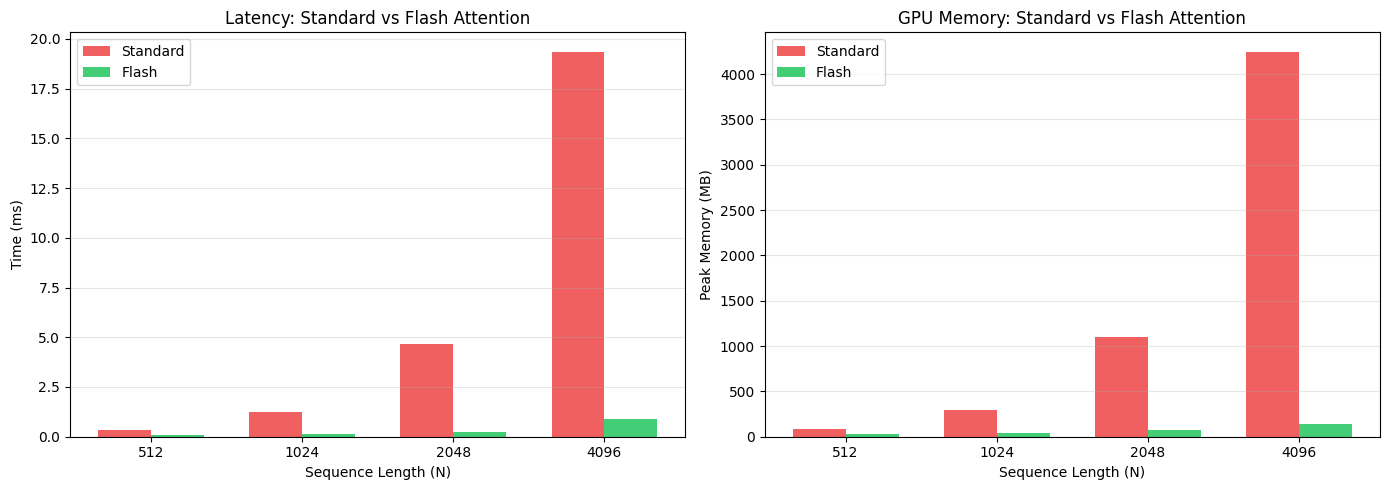

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = df['seq_len'].values
bar_w = 0.35
idx = np.arange(len(x))

# --- Time ---
ax = axes[0]
ax.bar(idx - bar_w/2, df['std_time_ms'], bar_w, label='Standard', color='#ef4444', alpha=0.85)
ax.bar(idx + bar_w/2, df['flash_time_ms'], bar_w, label='Flash', color='#22c55e', alpha=0.85)
ax.set_xticks(idx)
ax.set_xticklabels(x)
ax.set_xlabel('Sequence Length (N)')
ax.set_ylabel('Time (ms)')
ax.set_title('Latency: Standard vs Flash Attention')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# --- Memory ---
ax = axes[1]
ax.bar(idx - bar_w/2, df['std_mem_MB'], bar_w, label='Standard', color='#ef4444', alpha=0.85)
ax.bar(idx + bar_w/2, df['flash_mem_MB'], bar_w, label='Flash', color='#22c55e', alpha=0.85)
ax.set_xticks(idx)
ax.set_xticklabels(x)
ax.set_xlabel('Sequence Length (N)')
ax.set_ylabel('Peak Memory (MB)')
ax.set_title('GPU Memory: Standard vs Flash Attention')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()